In [111]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
# Set a random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)
# Load the CSV files
mitbih_test = pd.read_csv('C:/Users/asena/Desktop/data_science/project_data/mitbih_test.csv', header=None)
mitbih_train = pd.read_csv('C:/Users/asena/Desktop/data_science/project_data/mitbih_train.csv', header=None)
ptbdb_abnormal = pd.read_csv('C:/Users/asena/Desktop/data_science/project_data/ptbdb_abnormal.csv', header=None)
ptbdb_normal = pd.read_csv('C:/Users/asena/Desktop/data_science/project_data/ptbdb_normal.csv', header=None)


# Preprocess the MIT-BIH dataset
def preprocess_data(data):
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    df = pd.DataFrame(X)
    df['label'] = y
    
    # Define number of samples per class
    num_samples_per_class = {0: 819, 1: 819, 2: 819, 3: 803, 4: 819}
    
    balanced_data = []
    for label, num_samples in num_samples_per_class.items():
        class_data = df[df['label'] == label]
        if len(class_data) > num_samples:
            class_data = resample(class_data, replace=False, n_samples=num_samples, random_state=random_seed)
        balanced_data.append(class_data)
        
    balanced_df = pd.concat(balanced_data)
    X_balanced = balanced_df.iloc[:, :-1].values
    y_balanced = balanced_df.iloc[:, -1].values
    
    scaler = StandardScaler()
    X_balanced = scaler.fit_transform(X_balanced)
    X_balanced = X_balanced.reshape((X_balanced.shape[0], X_balanced.shape[1], 1))
    return X_balanced, y_balanced

X_train, y_train = preprocess_data(mitbih_train)
X_test, y_test = preprocess_data(mitbih_test)


In [112]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, MaxPooling1D, Flatten, Add, GlobalAveragePooling1D

# Set a random seed for TensorFlow
tf.random.set_seed(random_seed)

# Define the Residual Block
def residual_block(x, filters, kernel_size=5, stride=1):
    res = x
    x = Conv1D(filters, kernel_size, strides=stride, padding='same', activation='relu')(x)
    x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    
    # Add the residual connection
    if res.shape[-1] != x.shape[-1] or stride != 1:
        res = Conv1D(filters, kernel_size=1, strides=stride, padding='same')(res)
    
    x = Add()([x, res])
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPooling1D(pool_size=5, strides=2, padding='same')(x)
    return x

# Define the ResNet Model
def create_resnet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu')(inputs)
    
    # Add 5 residual blocks
    for _ in range(5):
        x = residual_block(x, 32)
    
    x = GlobalAveragePooling1D()(x)
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

# Create the model
input_shape = (X_train.shape[1], 1)
num_classes = len(np.unique(y_train))
resnet_model = create_resnet(input_shape, num_classes)

# Compile the model
resnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Measure training time
import time
start_time = time.time()
history = resnet_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
end_time = time.time()

training_time = end_time - start_time
print(f"Total Training Time: {training_time:.2f} seconds")



Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4800 - loss: 1.2364 - val_accuracy: 0.0000e+00 - val_loss: 3.8623
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7147 - loss: 0.7988 - val_accuracy: 0.0000e+00 - val_loss: 3.2208
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7697 - loss: 0.6361 - val_accuracy: 0.0000e+00 - val_loss: 2.9365
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7953 - loss: 0.5840 - val_accuracy: 0.0000e+00 - val_loss: 2.8491
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8034 - loss: 0.5364 - val_accuracy: 0.0000e+00 - val_loss: 2.5938
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8104 - loss: 0.5133 - val_accuracy: 0.0000e+00 - val_loss: 2.5625
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8406 - loss: 0.4540 - val_accuracy: 0.0485 - val_loss: 1.9543
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8522 - loss: 0.3948 - 

In [104]:
# Extract features from the last convolutional layer
feature_extractor = Model(inputs=resnet_model.input, outputs=resnet_model.layers[-5].output)

# Extract features from training and test sets
train_features = feature_extractor.predict(X_train)
test_features = feature_extractor.predict(X_test)

# Flatten the features for the fully connected network
train_features_flat = train_features.reshape(train_features.shape[0], -1)
test_features_flat = test_features.reshape(test_features.shape[0], -1)



123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [105]:
# Dummy binary labels for MI prediction, assuming y_train and y_test are already MI labels
# Adjust this based on actual labels for MI prediction
y_train_mi = (y_train == 1).astype(int)  # Assuming label 1 is MI, modify as needed
y_test_mi = (y_test == 1).astype(int)

# Define the MI Predictor model
def create_mi_predictor(input_shape):
    inputs = Input(shape=input_shape)
    x = Dense(32, activation='relu')(inputs)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification for MI
    model = Model(inputs, outputs)
    return model

mi_input_shape = (train_features_flat.shape[1],)
mi_predictor = create_mi_predictor(mi_input_shape)

# Compile the MI Predictor model
mi_predictor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the MI Predictor model
history_mi = mi_predictor.fit(train_features_flat, y_train_mi, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6837 - loss: 0.7287 - val_accuracy: 0.9872 - val_loss: 0.1271
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9551 - loss: 0.1142 - val_accuracy: 0.9911 - val_loss: 0.0671
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9687 - loss: 0.0830 - val_accuracy: 0.9923 - val_loss: 0.0525
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9736 - loss: 0.0702 - val_accuracy: 0.9923 - val_loss: 0.0463
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9763 - loss: 0.0623 - val_accuracy: 0.9923 - val_loss: 0.0432
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9780 - loss: 0.0569 - val_accuracy: 0.9923 - val_loss: 0.0402
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9797 - loss: 0.0538 - val_accuracy: 0.9923 - val_loss: 0.0379
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9823 - loss: 0.0508 - val_accuracy: 0.9923 - val_loss:

In [113]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8485 - loss: 0.6176
Model Accuracy: 85.48%


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.9352 - loss: 0.2908
MI Predictor Model Accuracy: 95.15%
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step


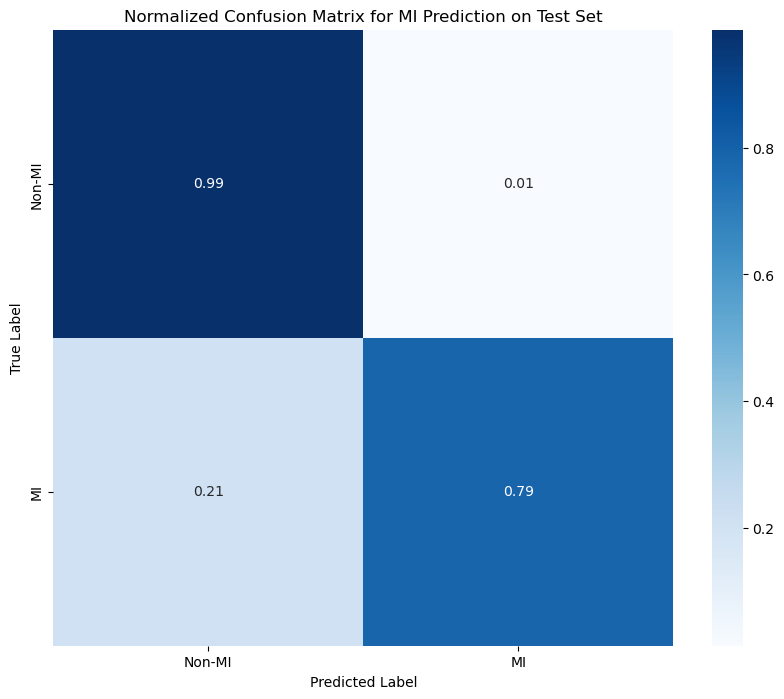

Classification Report:
               precision    recall  f1-score   support

      Non-MI       0.96      0.99      0.97      2619
          MI       0.93      0.79      0.85       556

    accuracy                           0.95      3175
   macro avg       0.94      0.89      0.91      3175
weighted avg       0.95      0.95      0.95      3175



In [114]:
# Evaluate the MI Predictor model
mi_loss, mi_accuracy = mi_predictor.evaluate(test_features_flat, y_test_mi)
print(f"MI Predictor Model Accuracy: {mi_accuracy * 100:.2f}%")

# Make predictions on the test set
y_pred_mi = mi_predictor.predict(test_features_flat)
y_pred_mi_classes = (y_pred_mi > 0.5).astype(int)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_mi, y_pred_mi_classes)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=['Non-MI', 'MI'], yticklabels=['Non-MI', 'MI'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix for MI Prediction on Test Set')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(y_test_mi, y_pred_mi_classes, target_names=['Non-MI', 'MI']))



100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8701 - loss: 0.3855
Test Accuracy: 82.52%
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


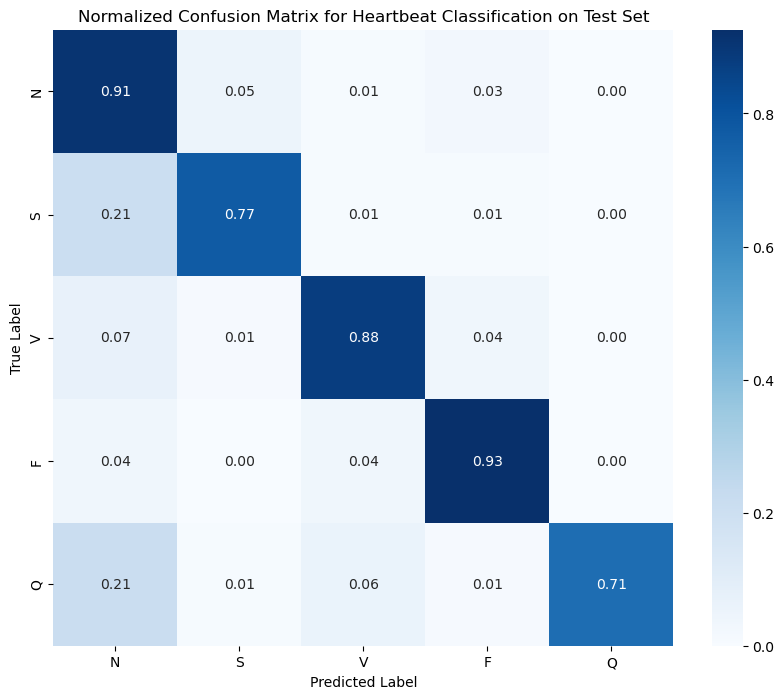

Classification Report:
               precision    recall  f1-score   support

           N       0.68      0.91      0.78       819
           S       0.88      0.77      0.82       556
           V       0.91      0.88      0.89       819
           F       0.69      0.93      0.79       162
           Q       0.99      0.71      0.83       819

    accuracy                           0.83      3175
   macro avg       0.83      0.84      0.82      3175
weighted avg       0.86      0.83      0.83      3175



In [115]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test set
test_loss, test_accuracy = resnet_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Make predictions on the test set
y_pred = np.argmax(resnet_model.predict(X_test), axis=-1)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=['N', 'S', 'V', 'F', 'Q'], yticklabels=['N', 'S', 'V', 'F', 'Q'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix for Heartbeat Classification on Test Set')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['N', 'S', 'V', 'F', 'Q']))
